# Modules

In [ ]:
from dateutil import tz

import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

from longitudinal_arm_swing.constants import *

# Constants

In [ ]:
from_tz = tz.gettz('UTC')
to_tz = tz.gettz('Europe/Amsterdam')
round_minutes = 5

# Load

In [ ]:
d_stats = {
    'gait': {},
    'arm_swing': {}
}

for week_nr in [2]:
    with open(os.path.join(r'C:\Users\\z665206\Documents\PhD\data\longitudinal\stats', f'gait_stats_week{week_nr}.json'), 'r') as f:
        d_stats['gait'][str(week_nr)] = json.load(f)
    with open(os.path.join(r'C:\Users\\z665206\Documents\PhD\data\longitudinal\stats', f'arm_activity_stats_week{week_nr}.json'), 'r') as f:
        d_stats['arm_swing'][str(week_nr)] = json.load(f)


# Process

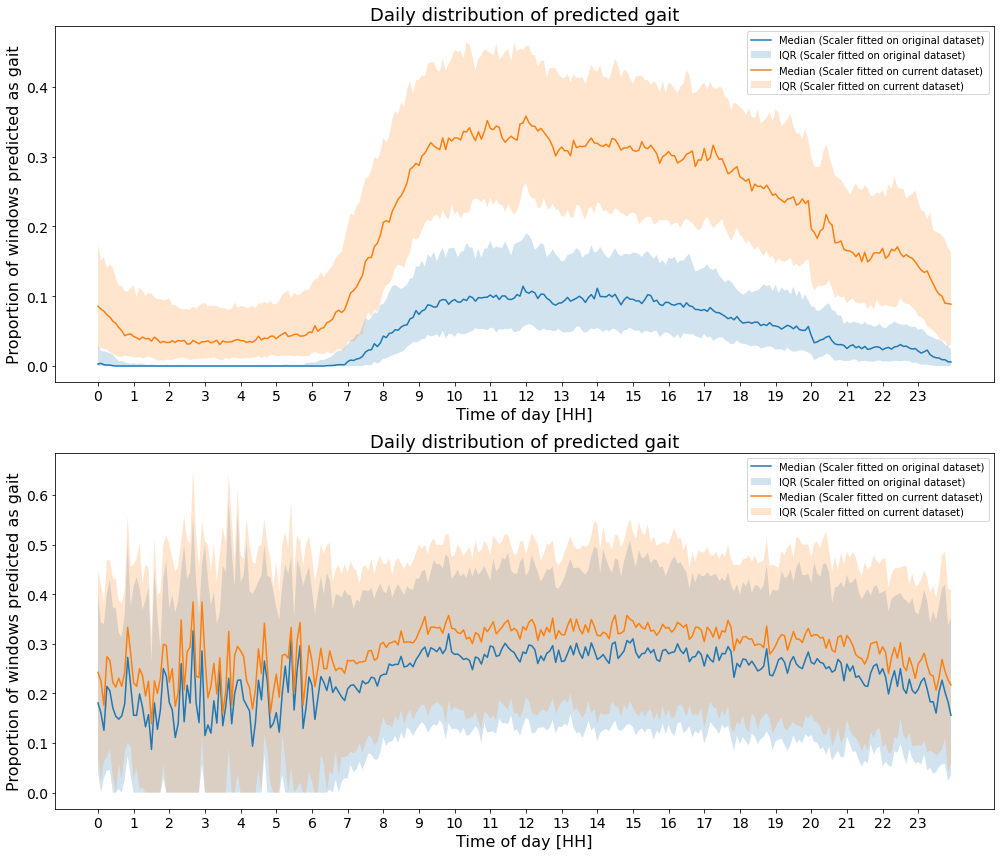

In [ ]:
suffixes = {
    'pdh': 'Scaler fitted on original dataset',
    'subset': 'Scaler fitted on current dataset',
}
week_nr = '2'
      
fig, ax = plt.subplots(nrows=2, figsize=(14,12))

for i, activity in enumerate(d_stats.keys()):
    for suffix, suffix_label in suffixes.items():
        for subject in d_stats[activity][week_nr].keys():
            if suffix not in d_stats[activity][week_nr][subject].keys():
                continue
            for hour in d_stats[activity][week_nr][subject][suffix]['hour_minutes'].keys():
                for minute in d_stats[activity][week_nr][subject][suffix]['hour_minutes'][hour].keys():
                    if 'pred_pos_s' not in d_stats[activity][week_nr][subject][suffix]['hour_minutes'][hour][minute].keys():
                        d_stats[activity][week_nr][subject][suffix]['hour_minutes'][hour][minute]['pred_pos_s'] = 0
                    if 'pred_neg_s' not in d_stats[activity][week_nr][subject][suffix]['hour_minutes'][hour][minute].keys():
                        d_stats[activity][week_nr][subject][suffix]['hour_minutes'][hour][minute]['pred_neg_s'] = 0

        d_prop_detailed = {}
        for hour in range(24):
            for minute in range(0, 60, 5):
                d_prop_detailed[str(hour+minute/60)] = {}
                if suffix not in d_stats[activity][week_nr][subject].keys():
                    continue
                minute_stats = [d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] / (d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] + d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)]['pred_neg_s']) for x in d_stats[activity][week_nr].keys() if str(hour) in d_stats[activity][week_nr][x][suffix]['hour_minutes'].keys() and str(minute) in d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)].keys() and d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] + d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)]['pred_neg_s'] > 0]
                if len(minute_stats) > 0:
                    d_prop_detailed[str(hour+minute/60)]['gait'] = {
                        'q1': np.quantile([d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] / (d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] + d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)]['pred_neg_s']) for x in d_stats[activity][week_nr].keys() if str(hour) in d_stats[activity][week_nr][x][suffix]['hour_minutes'].keys() and str(minute) in d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)].keys() and d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] + d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)]['pred_neg_s'] > 0], 0.25),
                        'q2': np.quantile([d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] / (d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] + d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)]['pred_neg_s']) for x in d_stats[activity][week_nr].keys() if str(hour) in d_stats[activity][week_nr][x][suffix]['hour_minutes'].keys() and str(minute) in d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)].keys() and d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] + d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)]['pred_neg_s'] > 0], 0.5),
                        'q3': np.quantile([d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] / (d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] + d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)]['pred_neg_s']) for x in d_stats[activity][week_nr].keys() if str(hour) in d_stats[activity][week_nr][x][suffix]['hour_minutes'].keys() and str(minute) in d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)].keys() and d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)][f'pred_pos_s'] + d_stats[activity][week_nr][x][suffix]['hour_minutes'][str(hour)][str(minute)]['pred_neg_s'] > 0], 0.75)
                    }
                
        sns.lineplot(x=d_prop_detailed.keys(), y=[d_prop_detailed[x]['gait']['q2'] for x in d_prop_detailed if 'gait' in d_prop_detailed[x]], ax=ax[i], label=f'Median ({suffix_label})')
        ax[i].fill_between(x=d_prop_detailed.keys(), y1=[d_prop_detailed[x]['gait']['q1'] for x in d_prop_detailed if 'gait' in d_prop_detailed[x]], y2=[d_prop_detailed[x]['gait']['q3'] for x in d_prop_detailed if 'gait' in d_prop_detailed[x]], alpha=0.2, label=f'IQR ({suffix_label})')

        start, end = ax[i].get_xlim()
        ax[i].set_xticks(np.arange(0, 24*12, 12), [f'{x//12}' for x in range(0, 24*12, 12)])
        ax[i].set_title(f'Daily distribution of predicted gait', size=PLOT_TITLESIZE)
        ax[i].set_ylabel(f'Proportion of windows predicted as gait', size=PLOT_LABELSIZE)
        ax[i].set_xlabel('Time of day [HH]', size=PLOT_LABELSIZE)
        ax[i].legend()
        ax[i].tick_params(axis='both', labelsize=PLOT_TICKSIZE)

fig.tight_layout()

plt.show()